# Наївний класифікатор Баєса: фільтрація спаму

**Тема 7.** Застосуємо теорему Баєса для класифікації електронних листів на **spam (1)** та **not spam / ham (0)** на наборі *Email Spam Classification Dataset*.

**Мета:** попередньо обробити тексти засобами `nltk`, побудувати наївний баєсів класифікатор «з нуля» та проаналізувати, які слова найсильніше вказують на спам.

## 1. Завантаження набору даних

In [ ]:
!wget -O SpamEmailClassificationDataset.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true

## 2. Розпакування архіву

In [ ]:
!unzip -o SpamEmailClassificationDataset.zip

## 3. Імпорт бібліотек та завантаження ресурсів `nltk`

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import math
import glob, os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Завантажимо ресурси nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))

np.random.seed(42)
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/popovaganna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/popovaganna/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/popovaganna/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/popovaganna/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/popovaganna/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 4. Читання даних

Читаємо `combined_data.csv`. У файлі трапляється службовий рядок-дублікат заголовка (`label`), тож залишаємо лише коректні мітки `0`/`1` і приводимо їх до цілого типу.

In [4]:
csv_path = './combined_data.csv'
if not os.path.exists(csv_path):
    csv_path = glob.glob('**/combined_data.csv', recursive=True)[0]

df = pd.read_csv(csv_path)
print('Сирий розмір:', df.shape)

# Прибираємо можливий службовий рядок-заголовок і приводимо мітку до int
df = df[df['label'].isin(['0', '1', 0, 1])].copy()
df['label'] = df['label'].astype(int)
df = df.dropna(subset=['text']).reset_index(drop=True)
print('Після очищення:', df.shape)
df.head()

Сирий розмір: (14861, 2)
Після очищення: (14860, 2)


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [5]:
print('Розподіл класів у повному наборі:')
print(df['label'].value_counts())

Розподіл класів у повному наборі:
label
1    7813
0    7047
Name: count, dtype: int64


### Відбір збалансованої вибірки

Повний набір великий, тож для роботи беремо **по 2000 повідомлень кожного класу** (разом 4000) — так вибірка збалансована, а обчислення швидкі.

In [6]:
N_PER_CLASS = 2000
spam = df[df['label'] == 1].sample(N_PER_CLASS, random_state=42)
ham  = df[df['label'] == 0].sample(N_PER_CLASS, random_state=42)
df = pd.concat([spam, ham]).sample(frac=1, random_state=42).reset_index(drop=True)
print('Розмір вибірки:', df.shape)
print(df['label'].value_counts())

Розмір вибірки: (4000, 2)
label
1    2000
0    2000
Name: count, dtype: int64


## 5. Візуалізація розподілу класів

/var/folders/vw/ty8wgr1n0237_dlxkbcl8rvh0000gn/T/ipykernel_9677/1472797831.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=axes[0], palette=['#4c9f70', '#e07b39'])
/var/folders/vw/ty8wgr1n0237_dlxkbcl8rvh0000gn/T/ipykernel_9677/1472797831.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(labels)


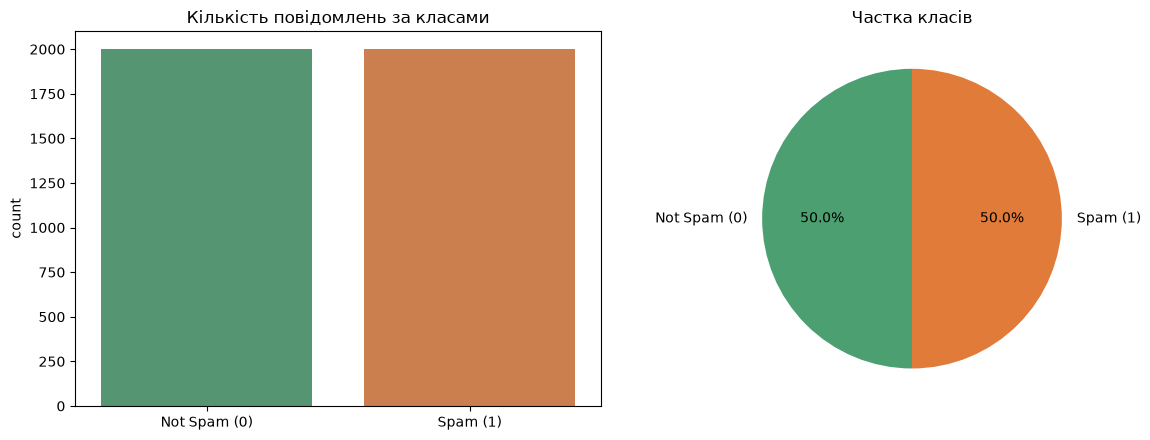

In [7]:
counts = df['label'].value_counts().sort_index()
labels = ['Not Spam (0)', 'Spam (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x='label', data=df, ax=axes[0], palette=['#4c9f70', '#e07b39'])
axes[0].set_xticklabels(labels)
axes[0].set_title('Кількість повідомлень за класами')
axes[0].set_xlabel('')

axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4c9f70', '#e07b39'], startangle=90)
axes[1].set_title('Частка класів')
plt.tight_layout()
plt.show()

## 6. Попередня обробка тексту

До кожного повідомлення застосовуємо:
1. видалення всього, крім літер, та приведення до **нижнього регістру**;
2. **лематизацію** — приведення слів до словникової форми (`WordNetLemmatizer`);
3. видалення **стоп-слів**;
4. видалення **повторів** слів у межах повідомлення (`set`).

In [8]:
corpus = []
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

for document in df['text']:
    document = re.sub('[^a-zA-Z]', ' ', document).lower()
    document = document.split()
    document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
    document = list(set(document))      # видаляємо повтори слів
    document = ' '.join(document)
    corpus.append(document)

df['text'] = corpus
df.head()

,label,text
0,1,found weliable secular problem star statecraft...
1,0,discussion temporarily go possible side verify...
2,1,leading check disc operation pc st big hf pqi ...
3,0,proof gssapi escapelong work linux check happy...
4,0,within connection exit minute afaik port mon t...


## 7. Підготовка структур даних

Ділимо вибірку на тренувальну (80%) і тестову (20%) частини та формуємо структури, як у конспекті:
- **`train_spam`** / **`train_ham`** — словники `{слово: кількість появ}` по всіх тренувальних повідомленнях відповідного класу;
- **`test_emails`** — словник тестових повідомлень `{індекс: список слів}`.

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label'])
print('train:', train_df.shape[0], ' test:', test_df.shape[0])


def build_word_counts(frame):
    """Словник {слово: сумарна кількість появ у повідомленнях класу}."""
    counts = {}
    for text in frame['text']:
        for word in text.split():
            counts[word] = counts.get(word, 0) + 1
    return counts


train_spam = build_word_counts(train_df[train_df['label'] == 1])
train_ham  = build_word_counts(train_df[train_df['label'] == 0])

test_emails = {i: text.split() for i, text in enumerate(test_df['text'])}
y_test = test_df['label'].values

print('Унікальних слів у spam:', len(train_spam))
print('Унікальних слів у ham: ', len(train_ham))
print('Тестових повідомлень:  ', len(test_emails))

train: 3200  test: 800
Унікальних слів у spam: 27968
Унікальних слів у ham:  23785
Тестових повідомлень:   800


## 8. Наївний класифікатор Баєса

За теоремою Баєса для повідомлення зі слів $w_1, \dots, w_k$ порівнюємо:
$$P(spam \mid words) \propto P(spam)\prod_i P(w_i \mid spam), \qquad P(ham \mid words) \propto P(ham)\prod_i P(w_i \mid ham).$$

Ймовірності слів оцінюємо з **згладжуванням Лапласа** (щоб уникнути нульових ймовірностей для невідомих слів):
$$P(w \mid spam) = \frac{count_{spam}(w) + 1}{N_{spam} + V},$$
де $N_{spam}$ — загальна кількість слів у спам-класі, $V$ — розмір словника.
Обчислення ведемо в **логарифмах**, щоб не втратити точність на добутках малих чисел.

In [10]:
# Параметри моделі
vocabulary = set(train_spam) | set(train_ham)
V = len(vocabulary)
N_spam = sum(train_spam.values())
N_ham  = sum(train_ham.values())

n_spam_docs = (train_df['label'] == 1).sum()
n_ham_docs  = (train_df['label'] == 0).sum()
log_prior_spam = math.log(n_spam_docs / (n_spam_docs + n_ham_docs))
log_prior_ham  = math.log(n_ham_docs  / (n_spam_docs + n_ham_docs))


def log_prob_word(word, class_counts, class_total):
    """Логарифм P(word | class) зі згладжуванням Лапласа."""
    return math.log((class_counts.get(word, 0) + 1) / (class_total + V))


def classify(words):
    """Повертає 1 (spam) або 0 (ham) для списку слів повідомлення."""
    score_spam = log_prior_spam
    score_ham = log_prior_ham
    for word in words:
        score_spam += log_prob_word(word, train_spam, N_spam)
        score_ham += log_prob_word(word, train_ham, N_ham)
    return 1 if score_spam > score_ham else 0

### Оцінка якості на тестовій вибірці

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.array([classify(test_emails[i]) for i in range(len(test_emails))])
accuracy = (y_pred == y_test).mean()
print(f'Точність (accuracy): {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

Точність (accuracy): 0.9387

              precision    recall  f1-score   support

    Not Spam       0.90      0.98      0.94       400
        Spam       0.98      0.89      0.94       400

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



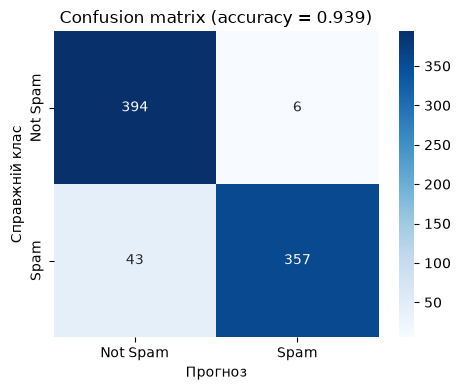

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Прогноз')
plt.ylabel('Справжній клас')
plt.title(f'Confusion matrix (accuracy = {accuracy:.3f})')
plt.tight_layout()
plt.show()

## 9. Аналіз: які слова найсильніше вказують на спам?

Для кожного слова рахуємо **відношення правдоподібностей** $\dfrac{P(w \mid spam)}{P(w \mid ham)}$: чим воно більше, тим сильніше слово тягне класифікацію в бік спаму. Розглядаємо лише слова, що зустрілися в спамі достатньо часто, щоб відсіяти випадкові рідкісні токени.

In [13]:
MIN_COUNT = 10  # мінімальна кількість появ слова у спамі
rows = []
for word in vocabulary:
    c_spam = train_spam.get(word, 0)
    if c_spam < MIN_COUNT:
        continue
    p_spam = (c_spam + 1) / (N_spam + V)
    p_ham = (train_ham.get(word, 0) + 1) / (N_ham + V)
    rows.append((word, p_spam / p_ham, c_spam))

top_spam = pd.DataFrame(rows, columns=['word', 'likelihood_ratio', 'spam_count'])
top_spam = top_spam.sort_values('likelihood_ratio', ascending=False).head(20)
top_spam.reset_index(drop=True)

,word,likelihood_ratio,spam_count
0,pharmacy,112.417827,92
1,viagra,105.165064,86
2,cialis,95.494713,78
3,photoshop,77.362806,63
4,canadianpharmacy,70.110043,57
5,autodesk,65.274867,53
6,corel,62.857280,51
7,hk,62.454348,154
8,autocad,60.439692,49
9,csescapenumber,56.813310,46


/var/folders/vw/ty8wgr1n0237_dlxkbcl8rvh0000gn/T/ipykernel_9677/3477866150.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='likelihood_ratio', y='word',


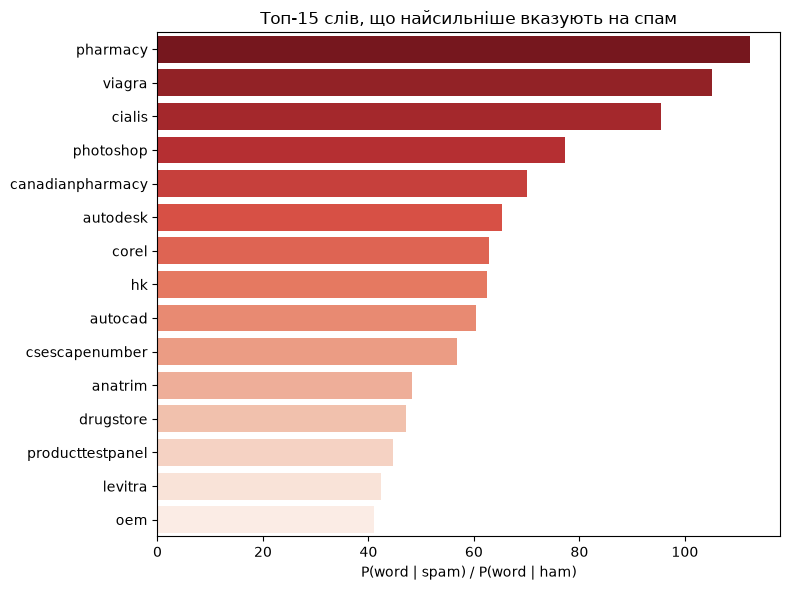

In [14]:
plt.figure(figsize=(8, 6))
sns.barplot(x='likelihood_ratio', y='word',
            data=top_spam.head(15), palette='Reds_r')
plt.xlabel('P(word | spam) / P(word | ham)')
plt.ylabel('')
plt.title('Топ-15 слів, що найсильніше вказують на спам')
plt.tight_layout()
plt.show()

## Висновок

Наївний баєсів класифікатор, реалізований «з нуля», показав високу якість фільтрації спаму (**accuracy ≈ 0.94** на збалансованій тестовій вибірці) — попри «наївне» припущення про незалежність слів.

**Що спрацювало:**
- **Попередня обробка `nltk`** (нижній регістр, лематизація, видалення стоп-слів і повторів) прибирає шум і зводить словоформи до спільної основи, зменшуючи словник і покращуючи оцінки ймовірностей.
- **Згладжування Лапласа** та обчислення в **логарифмах** роблять модель стійкою до невідомих слів і числово надійною.

**Аналіз ознак.** Слова з найбільшим відношенням правдоподібності — це класична спам-лексика: назви ліків та реклама (`viagra`, `cialis`, `pharmacy`, `levitra`), піратське ПЗ (`autocad`, `photoshop`, `corel`, `oem`) тощо. Саме такі слова дають найбільший внесок у рішення «spam», що добре узгоджується з інтуїцією та підтверджує інтерпретованість наївного Баєса: модель не лише класифікує, а й наочно показує, *за якими ознаками* вона це робить.